# 04d - Solid Model Comparisons

This notebook provides definitive comparison visualizations to clearly identify the winning models:
- **Relative Improvement**: Comparing ML models vs a Linear Regression baseline.
- **Metric Heatmap**: A color-coded overview of all metrics for all models.
- **Ranking Summary**: Visualizing which models consistently perform in the top 3.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACTS_DIR = BASE_DIR / 'artifacts'

all_metrics = pd.read_csv(ARTIFACTS_DIR / 'combined_all_metrics.csv')
print("Metrics loaded.")

Metrics loaded.


C:\Users\RITIK SINHA\AppData\Local\Temp\ipykernel_26760\1596182279.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x='model', y='Improvement (%)', palette=colors)


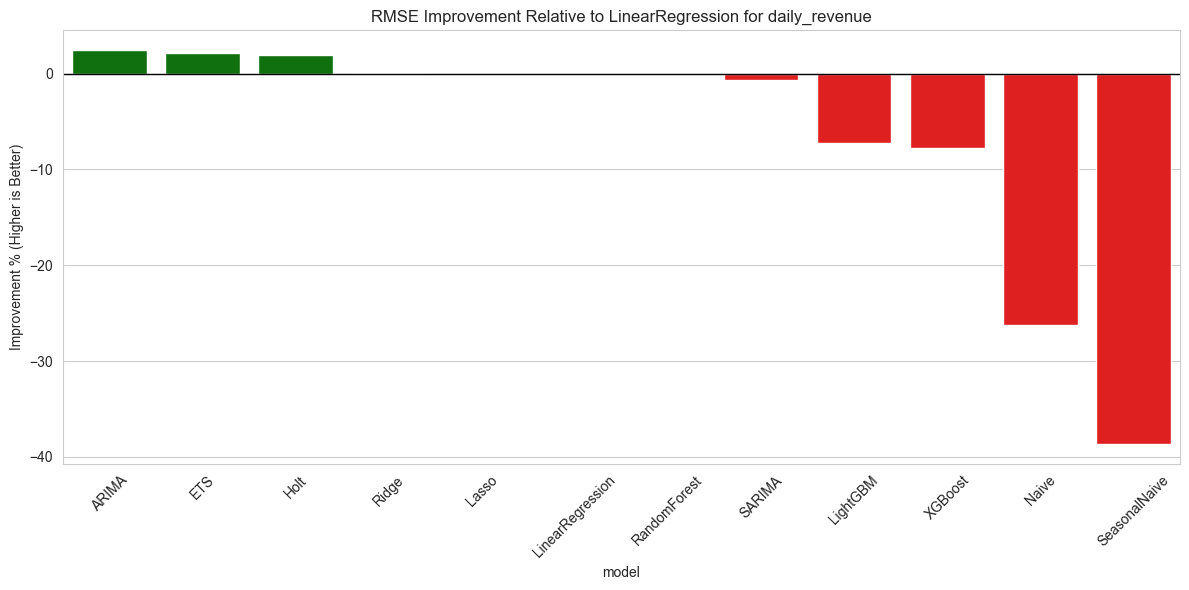

C:\Users\RITIK SINHA\AppData\Local\Temp\ipykernel_26760\1596182279.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x='model', y='Improvement (%)', palette=colors)


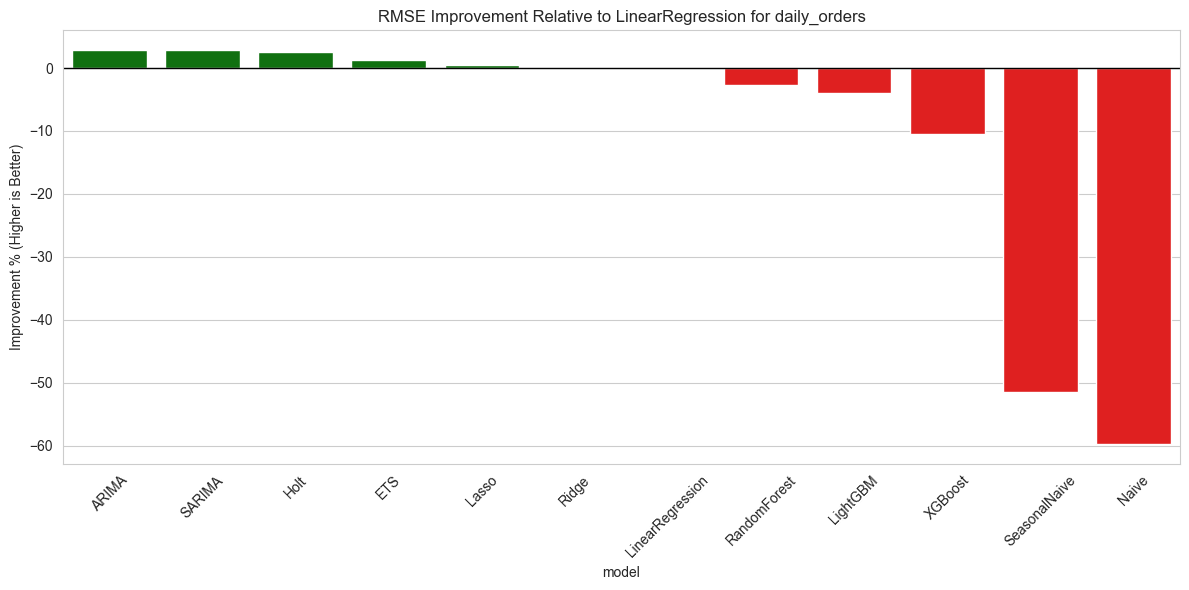

In [2]:
def plot_relative_improvement(df, target_name, baseline_model='LinearRegression'):
    subset = df[df['target'] == target_name].copy()
    baseline_val = subset[subset['model'] == baseline_model]['RMSE'].values[0]
    
    subset['Improvement (%)'] = (baseline_val - subset['RMSE']) / baseline_val * 100
    subset = subset.sort_values('Improvement (%)', ascending=False)
    
    plt.figure(figsize=(12, 6))
    colors = ['green' if x > 0 else 'red' for x in subset['Improvement (%)']]
    sns.barplot(data=subset, x='model', y='Improvement (%)', palette=colors)
    plt.title(f'RMSE Improvement Relative to {baseline_model} for {target_name}')
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=45)
    plt.ylabel('Improvement % (Higher is Better)')
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'04d_relative_improvement_{target_name}.png')
    plt.show()

plot_relative_improvement(all_metrics, 'daily_revenue')
plot_relative_improvement(all_metrics, 'daily_orders')

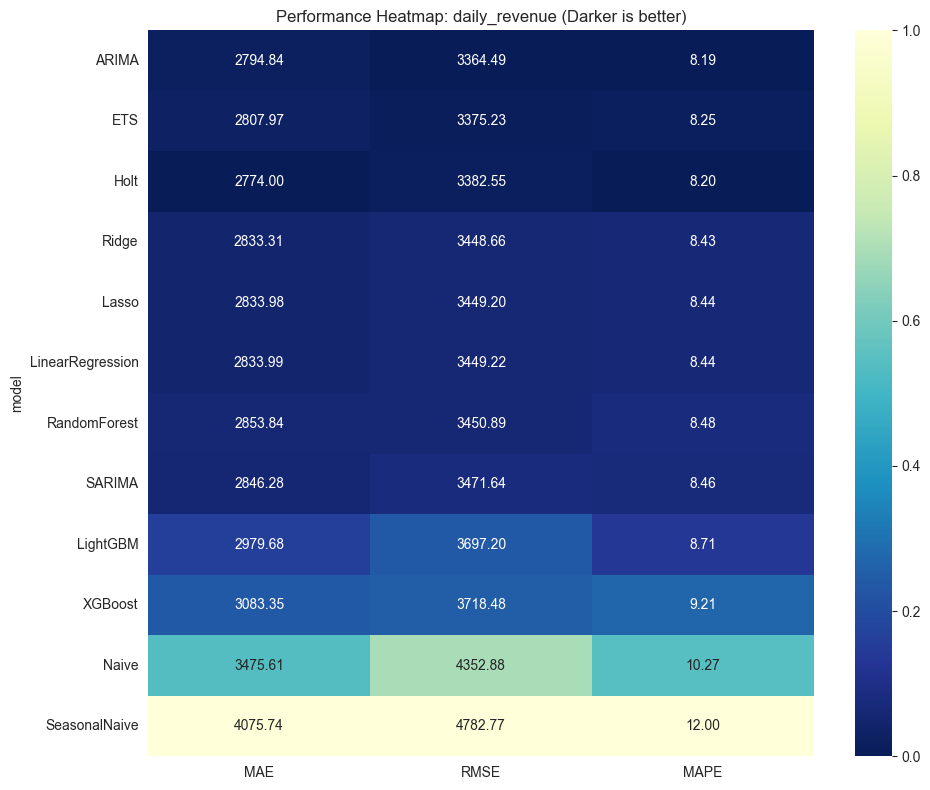

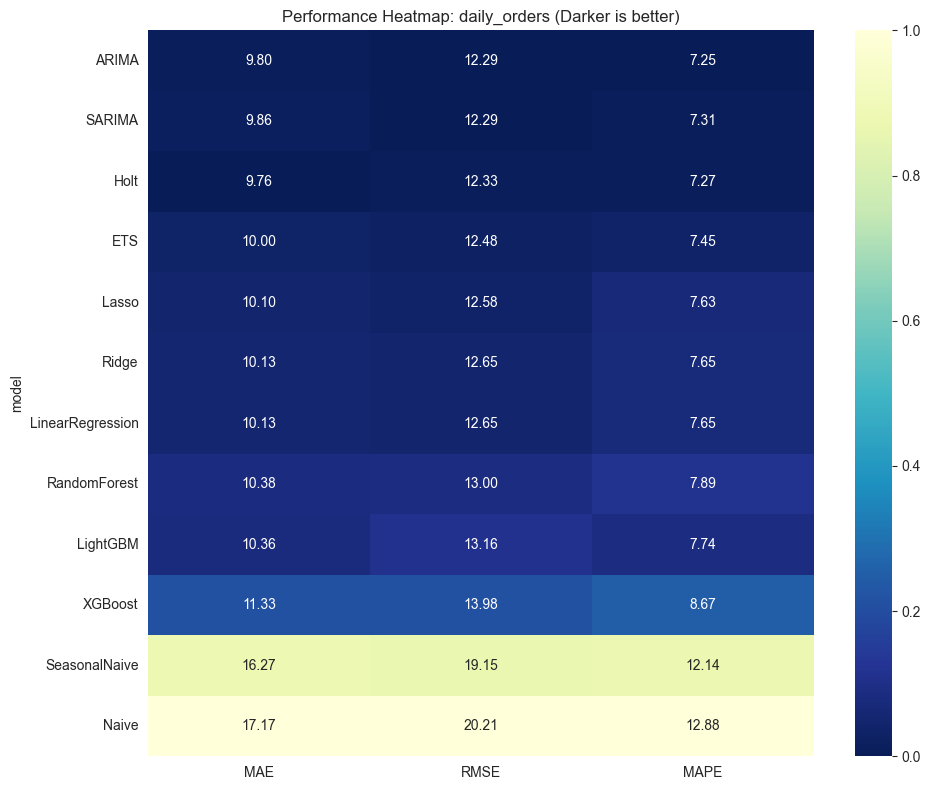

In [3]:
def plot_metric_heatmap(df, target_name):
    subset = df[df['target'] == target_name].set_index('model')[['MAE', 'RMSE', 'MAPE']]
    # Scale for heatmap visualization
    subset_norm = (subset - subset.min()) / (subset.max() - subset.min())
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(subset_norm, annot=subset, fmt=".2f", cmap='YlGnBu_r')
    plt.title(f'Performance Heatmap: {target_name} (Darker is better)')
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'04d_metric_heatmap_{target_name}.png')
    plt.show()

plot_metric_heatmap(all_metrics, 'daily_revenue')
plot_metric_heatmap(all_metrics, 'daily_orders')

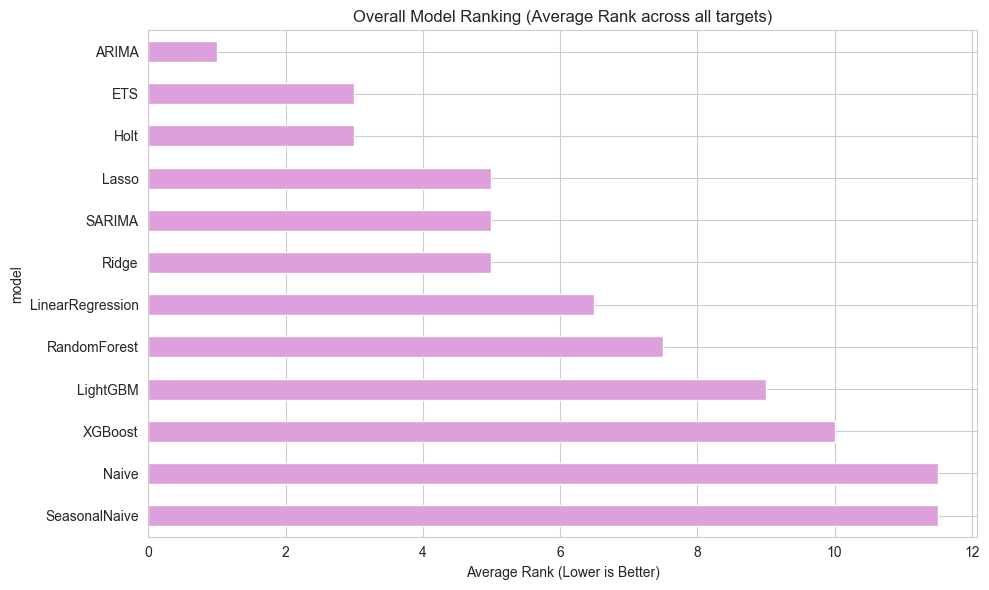

In [4]:
all_metrics['Rank'] = all_metrics.groupby('target')['RMSE'].rank()
rank_summary = all_metrics.groupby('model')['Rank'].mean().sort_values()

plt.figure(figsize=(10, 6))
rank_summary.plot(kind='barh', color='plum')
plt.gca().invert_yaxis()
plt.title('Overall Model Ranking (Average Rank across all targets)')
plt.xlabel('Average Rank (Lower is Better)')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '04d_overall_ranking.png')
plt.show()